In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("libraries loaded")

libraries loaded


In [26]:
# Loading the heart disease uci dataset
# Collected from 4 hospitals: Cleveland, Hungary, Switzerland, VA Long Beach
# 920 patients with 16 clinical features including lab results and demographics
# source: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data

df = pd.read_csv('heart_disease_uci.csv')

# Target column 'num' goes from 0 (no disease) to 4 (severe)
# Converting it to binary: 0 = no disease, 1 = has disease
# This makes it a classification problem which is standard for this type of analysis
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

print(f"Rows     : {df.shape[0]}")
print(f"Columns  : {df.shape[1]}")
print(f"Hospitals: {df['dataset'].nunique()} ({', '.join(df['dataset'].unique())})")
print(f"Patients With Heart Disease : {df['target'].sum()} ({df['target'].mean()*100:.1f}%)")
print(f"Patients Without            : {(df['target']==0).sum()} ({(df['target']==0).mean()*100:.1f}%)")
print()
df.head()

Rows     : 920
Columns  : 17
Hospitals: 4 (Cleveland, Hungary, Switzerland, VA Long Beach)
Patients With Heart Disease : 509 (55.3%)
Patients Without            : 411 (44.7%)



,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


In [28]:
# Checking data quality and handling missing values

print("Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(1)
missing_summary = pd.DataFrame({'missing count': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['missing count'] > 0])

print(f"\nduplicates: {df.duplicated().sum()}")

Missing Values per Column:
          missing count  Missing %
trestbps             59        6.4
chol                 30        3.3
fbs                  90        9.8
restecg               2        0.2
thalch               55        6.0
exang                55        6.0
oldpeak              62        6.7
slope               309       33.6
ca                  611       66.4
thal                486       52.8

duplicates: 0


In [30]:
# Dropping columns with too many missing values to be useful
df = df.drop(columns=['id', 'ca', 'thal', 'slope', 'num'])

# Filling remaining missing numeric values with the column median
# Median is better than mean here because medical data has outliers
numeric_cols = ['trestbps', 'chol', 'thalch', 'exang', 'oldpeak', 'fbs']
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Encoding categorical columns into numbers so the model can use them
le = LabelEncoder()
for col in ['sex', 'dataset', 'cp', 'restecg']:
    df[col] = le.fit_transform(df[col].astype(str))

# Converting boolean columns to integers
df['fbs']   = df['fbs'].astype(float).astype(int)
df['exang'] = df['exang'].astype(float).astype(int)

print(f"Missing Values Remaining: {df.isnull().sum().sum()}")
print(f"Final Dataset Shape: {df.shape}")
print()
display(df.describe().round(2))

Missing Values Remaining: 0
Final Dataset Shape: (920, 12)



,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,target
count,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00
mean,53.51,0.79,1.24,0.78,132.00,199.91,0.15,1.78,137.69,0.37,0.85,0.55
std,9.42,0.41,1.13,0.96,18.45,109.04,0.36,0.98,25.15,0.48,1.06,0.50
min,28.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,60.00,0.00,-2.60,0.00
25%,47.00,1.00,0.00,0.00,120.00,177.75,0.00,2.00,120.00,0.00,0.00,0.00
50%,54.00,1.00,1.00,0.00,130.00,223.00,0.00,2.00,140.00,0.00,0.50,1.00
75%,60.00,1.00,2.00,2.00,140.00,267.00,0.00,2.00,156.00,1.00,1.50,1.00
max,77.00,1.00,3.00,3.00,200.00,603.00,1.00,3.00,202.00,1.00,6.20,1.00


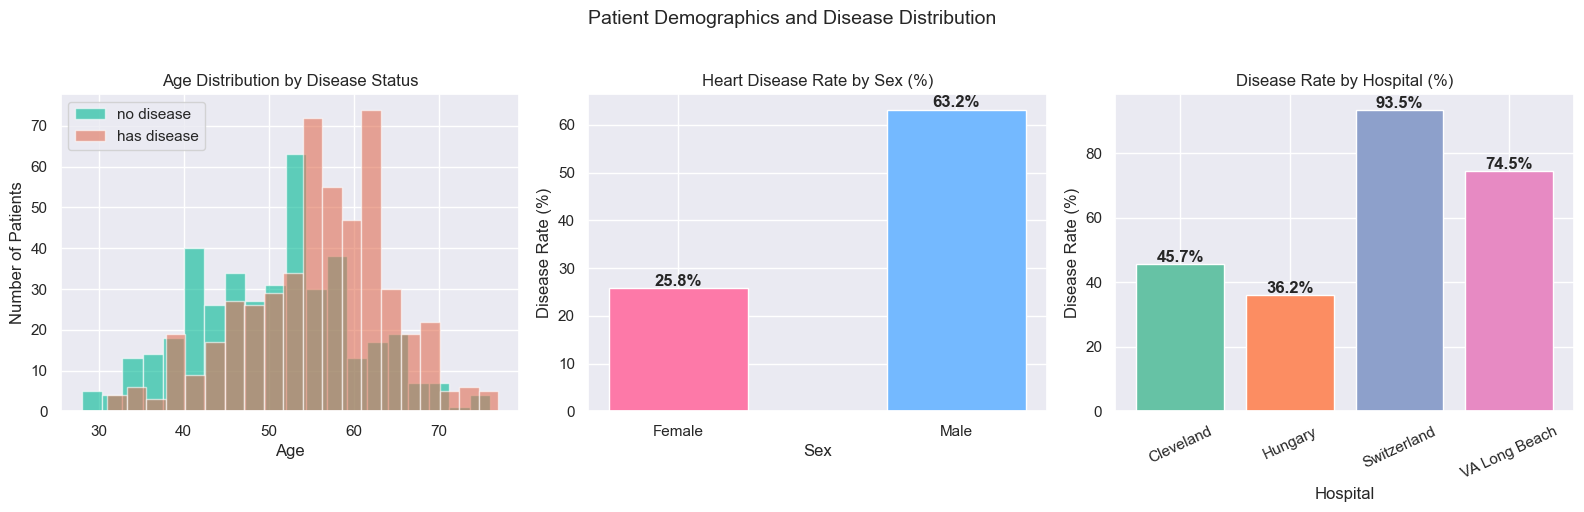

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution by disease status
df[df['target'] == 0]['age'].hist(ax=axes[0], alpha=0.6, color='#00b894',
                                   bins=20, label='no disease', edgecolor='white')
df[df['target'] == 1]['age'].hist(ax=axes[0], alpha=0.6, color='#e17055',
                                   bins=20, label='has disease', edgecolor='white')
axes[0].set_title('Age Distribution by Disease Status')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Patients')
axes[0].legend()

# Disease rate by sex (0=female, 1=male after encoding)
sex_disease = df.groupby('sex')['target'].mean() * 100
axes[1].bar(['Female', 'Male'], sex_disease.values,
            color=['#fd79a8', '#74b9ff'], edgecolor='white', width=0.5)
axes[1].set_title('Heart Disease Rate by Sex (%)')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Disease Rate (%)')
for i, v in enumerate(sex_disease.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Disease rate by hospital
hospital_names = ['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
dataset_disease = df.groupby('dataset')['target'].mean() * 100
axes[2].bar(range(len(dataset_disease)), dataset_disease.values,
            color=sns.color_palette('Set2', len(dataset_disease)), edgecolor='white')
axes[2].set_title('Disease Rate by Hospital (%)')
axes[2].set_xlabel('Hospital')
axes[2].set_ylabel('Disease Rate (%)')
axes[2].set_xticks(range(len(dataset_disease)))
axes[2].set_xticklabels(hospital_names, rotation=25)
for i, v in enumerate(dataset_disease.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Patient Demographics and Disease Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig1_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

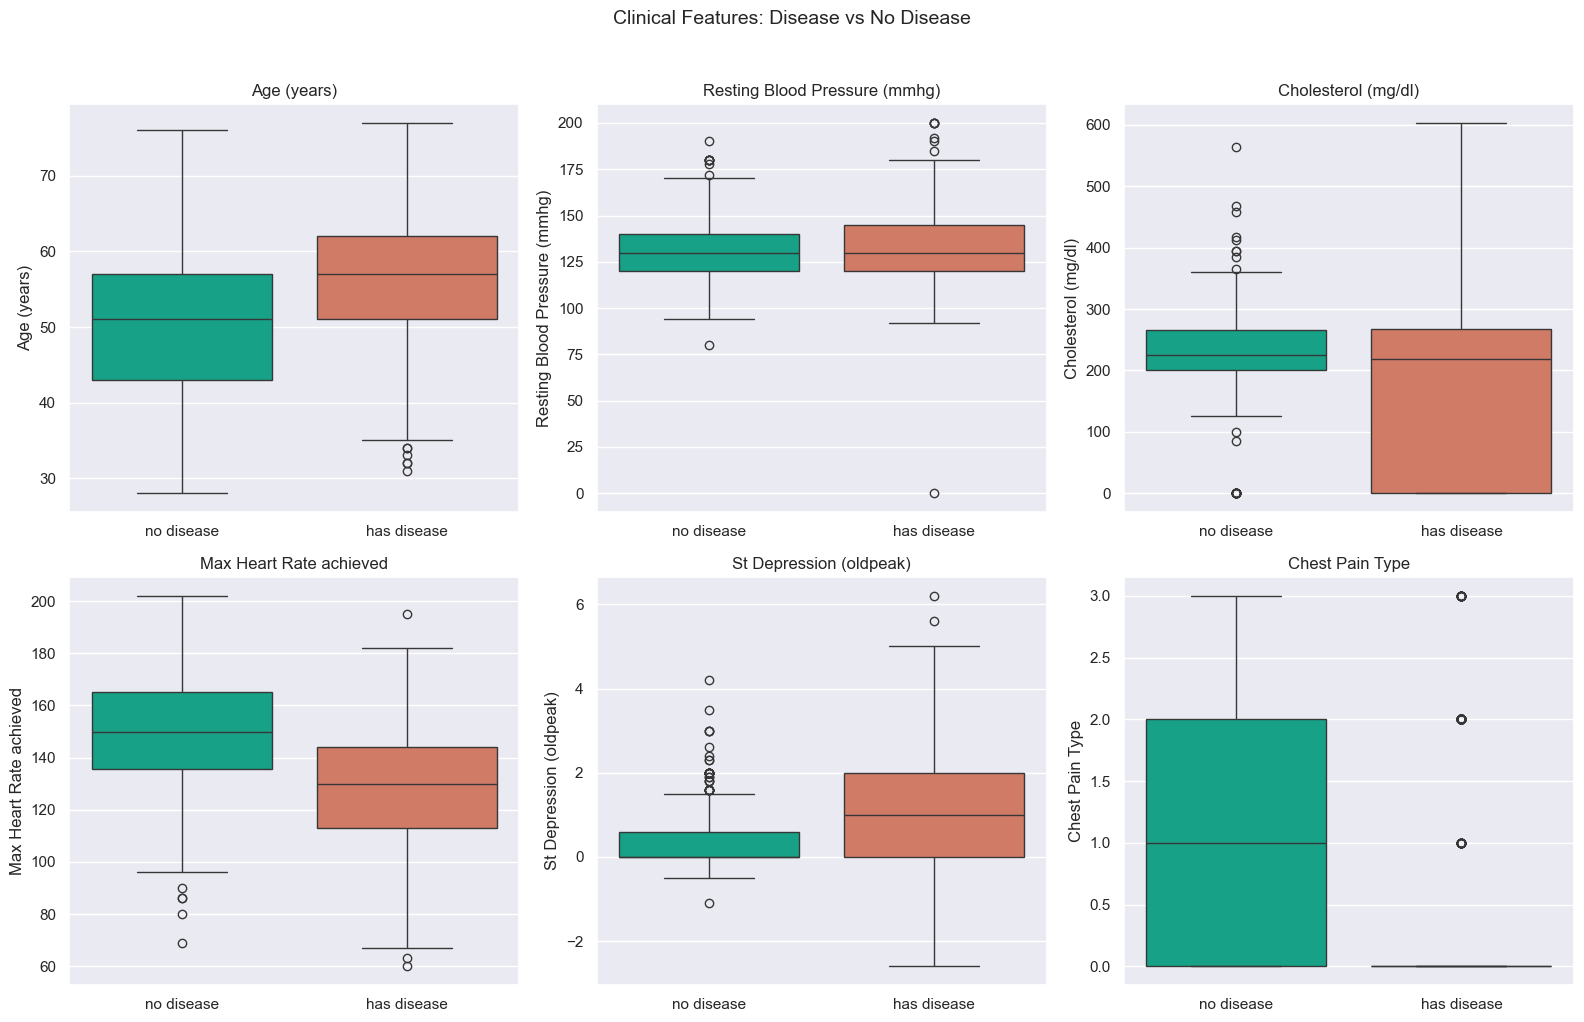

Patients with disease tend to have higher blood pressure, lower max heart rate,
and higher st depression values compared to healthy patients


In [34]:
# Comparing key clinical measurements between patients with and without heart disease

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

clinical = {
    'age':      'Age (years)',
    'trestbps': 'Resting Blood Pressure (mmhg)',
    'chol':     'Cholesterol (mg/dl)',
    'thalch':   'Max Heart Rate achieved',
    'oldpeak':  'St Depression (oldpeak)',
    'cp':       'Chest Pain Type'
}

df['target_str'] = df['target'].map({0: 'no disease', 1: 'has disease'})

for ax, (col, label) in  zip(axes.flatten(), clinical.items()):
    sns.boxplot(data=df, x='target_str', y=col,
                order=['no disease', 'has disease'],
                palette={'no disease': '#00b894', 'has disease': '#e17055'},
                ax=ax)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel(label)

plt.suptitle('Clinical Features: Disease vs No Disease', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig2_clinical_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Patients with disease tend to have higher blood pressure, lower max heart rate,")
print("and higher st depression values compared to healthy patients")

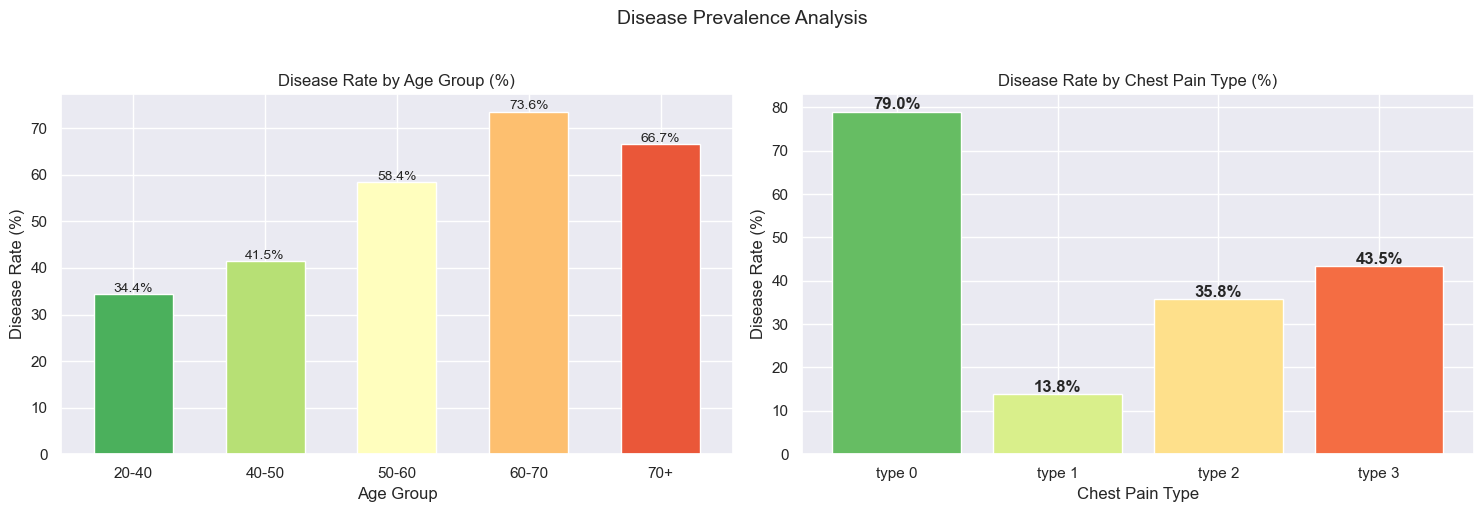

In [36]:
# Looking at disease rate across age groups and chest pain types

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Disease rate by age group
df['age_group'] = pd.cut(df['age'], bins=[20, 40, 50, 60, 70, 90],
                          labels=['20-40', '40-50', '50-60', '60-70', '70+'])
age_disease = df.groupby('age_group', observed=True)['target'].mean() * 100
age_disease.plot(kind='bar', ax=axes[0],
                 color=sns.color_palette('RdYlGn_r', len(age_disease)),
                 edgecolor='white', width=0.6)
axes[0].set_title('Disease Rate by Age Group (%)')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Disease Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                     ha='center', fontsize=10)

# Chest Pain Type vs Disease
cp_disease = df.groupby('cp')['target'].mean() * 100
cp_labels  = [f'type {i}' for i in cp_disease.index]
axes[1].bar(cp_labels, cp_disease.values,
            color=sns.color_palette('RdYlGn_r', len(cp_disease)), edgecolor='white')
axes[1].set_title('Disease Rate by Chest Pain Type (%)')
axes[1].set_xlabel('Chest Pain Type')
axes[1].set_ylabel('Disease Rate (%)')
for i, v in enumerate(cp_disease.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Disease Prevalence Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig3_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

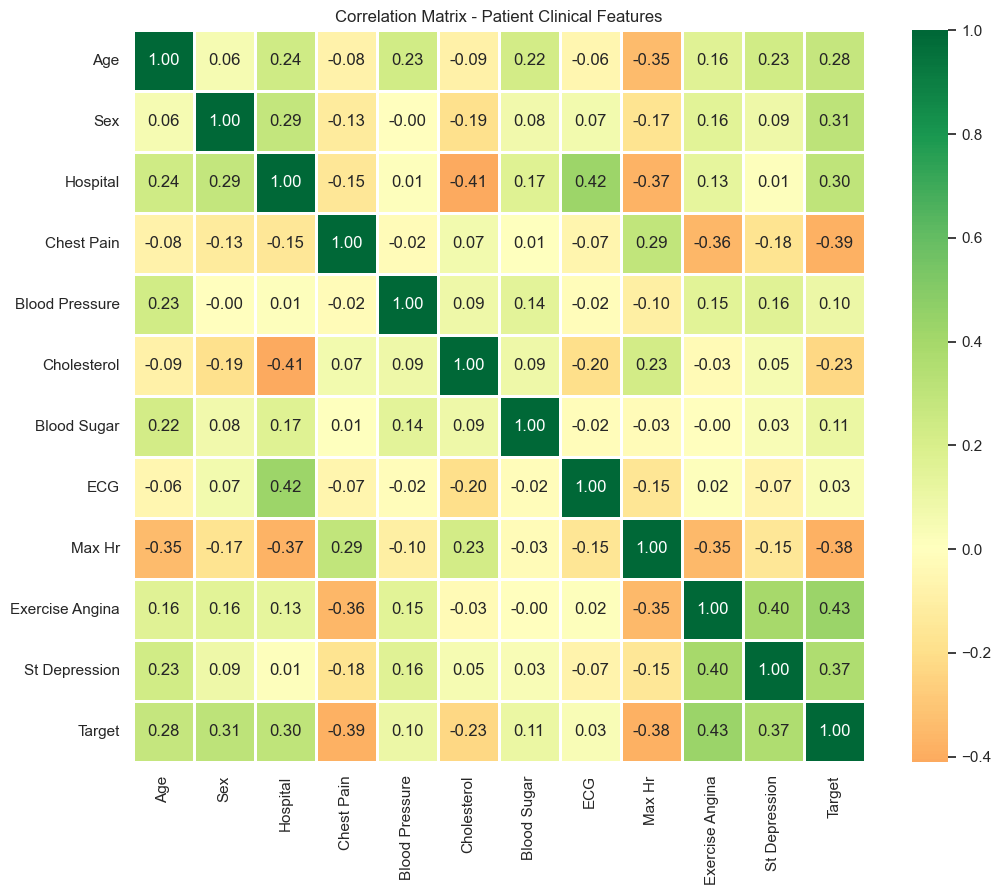

Chest pain type and max heart rate are most correlated with disease
st depression and exercise-induced angina also show strong associations


In [38]:
# Checking how all clinical variables relate to each other
# And which ones are most associated with the disease target

corr = df.drop(columns=['age_group', 'target_str']).corr()

corr.columns = ['Age', 'Sex', 'Hospital', 'Chest Pain', 'Blood Pressure',
                'Cholesterol', 'Blood Sugar', 'ECG', 'Max Hr',
                'Exercise Angina', 'St Depression', 'Target']
corr.index = corr.columns

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.8, square=True)
plt.title('Correlation Matrix - Patient Clinical Features')
plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chest pain type and max heart rate are most correlated with disease")
print("st depression and exercise-induced angina also show strong associations")

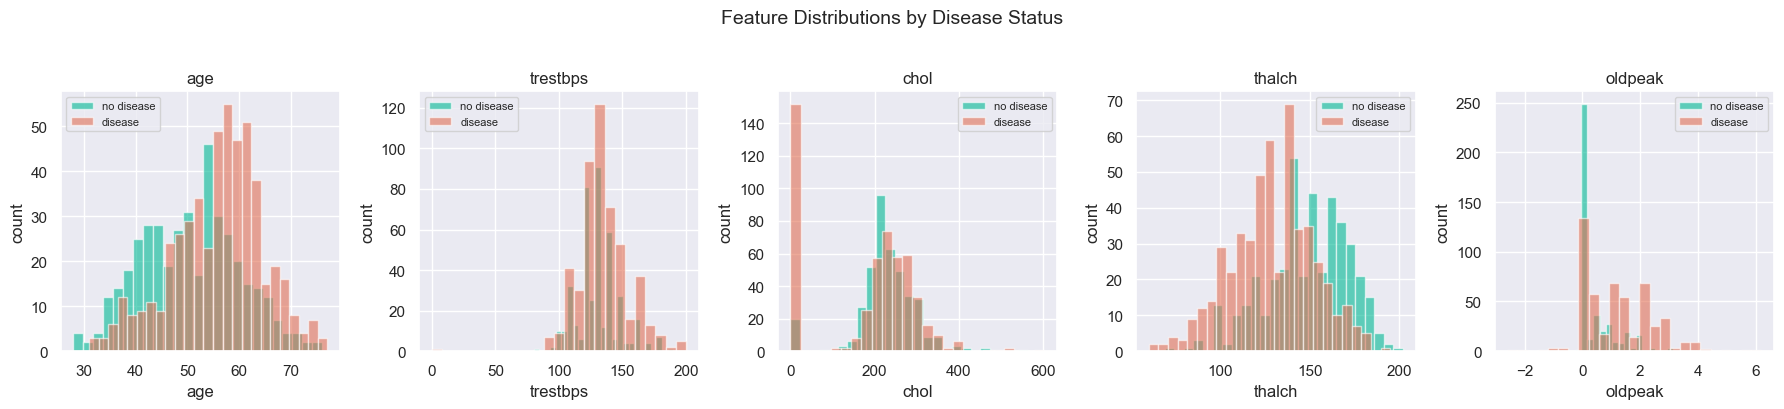

In [40]:
# Distribution plots for all numeric features
# Helps spot outliers and understand the spread of each variable

numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 4))

for ax, col in zip(axes, numeric_features):
    df[df['target'] == 0][col].hist(ax=ax, alpha=0.6, color='#00b894',
                                     bins=25, label='no disease', edgecolor='white')
    df[df['target'] == 1][col].hist(ax=ax, alpha=0.6, color='#e17055',
                                     bins=25, label='disease', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Disease Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig5_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# Training three classification models to predict whether a patient has heart disease
# Using logistic regression, decision tree, and random forest
# Evaluation uses accuracy, precision, recall, f1 and auc-roc as specified

features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
            'restecg', 'thalch', 'exang', 'oldpeak', 'dataset']
target   = 'target'

X = df[features]
y = df[target]

# Scaling features so logistic regression works properly
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Rraining on {X_train.shape[0]} Patients")
print(f"Testing on  {X_test.shape[0]} Patients\n")

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds    = model.predict(X_test)
    probs    = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    auc  = roc_auc_score(y_test, probs)
    cv   = cross_val_score(model, X_scaled, y, cv=5, scoring='roc_auc').mean()

    results.append({
        'model':        name,
        'accuracy':     round(acc, 4),
        'precision':    round(prec, 4),
        'recall':       round(rec, 4),
        'f1 score':     round(f1, 4),
        'auc-roc':      round(auc, 4),
        'cross val auc': round(cv, 4)
    })
    print(f"{name:<22}  acc={acc:.4f}  auc={auc:.4f}  recall={rec:.4f}  cv={cv:.4f}")

results_df = pd.DataFrame(results)
print()
display(results_df)

Rraining on 736 Patients
Testing on  184 Patients

Logistic Regression     acc=0.8261  auc=0.8965  recall=0.8627  cv=0.8675
Decision Tree           acc=0.8043  auc=0.8681  recall=0.8627  cv=0.7305
Random Forest           acc=0.8098  auc=0.9130  recall=0.8529  cv=0.8042



,model,accuracy,precision,recall,f1 score,auc-roc,cross val auc
0,Logistic Regression,0.8261,0.8302,0.8627,0.8462,0.8965,0.8675
1,Decision Tree,0.8043,0.8000,0.8627,0.8302,0.8681,0.7305
2,Random Forest,0.8098,0.8131,0.8529,0.8325,0.9130,0.8042


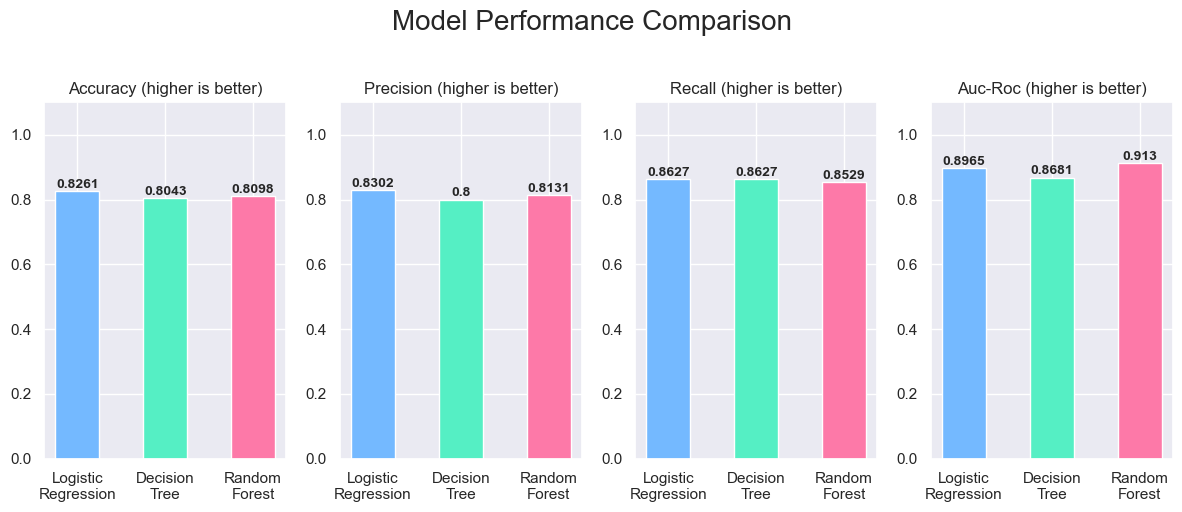

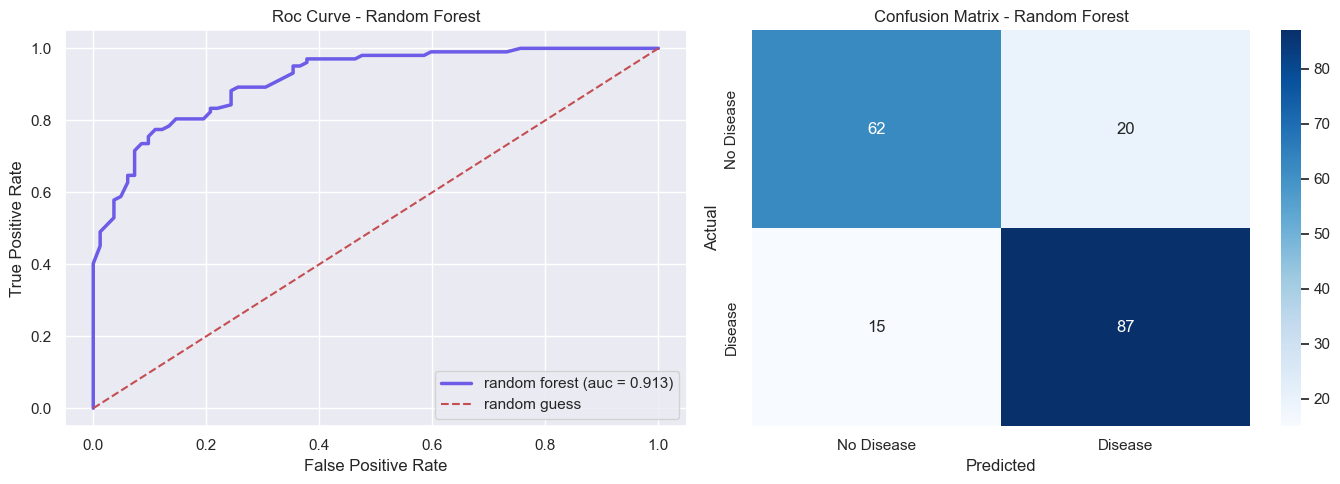

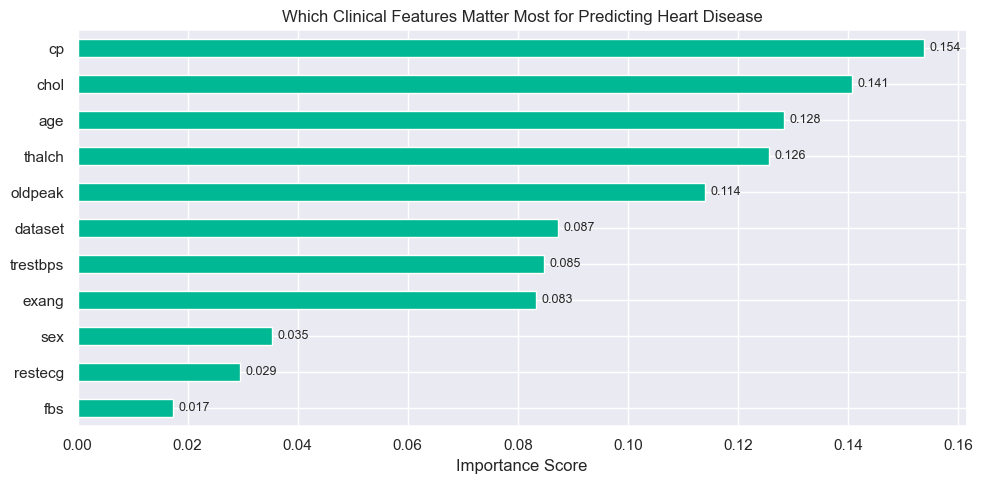

In [44]:
# Comparing all models visually and looking at the confusion matrix
# And roc curve for the best performing model

model_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
colors      = ['#74b9ff', '#55efc4', '#fd79a8']

fig, axes = plt.subplots(1, 4, figsize=(12, 5))

for i, (col, title) in enumerate([
    ('accuracy',  'Accuracy (higher is better)'),
    ('precision', 'Precision (higher is better)'),
    ('recall',    'Recall (higher is better)'),
    ('auc-roc',   'Auc-Roc (higher is better)')
]):
    bars = axes[i].bar(model_names, results_df[col],
                       color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(title)
    axes[i].set_ylim(0, 1.1)
    for bar, val in zip(bars, results_df[col]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     str(val), ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig('fig6_model_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve and confusion matrix for random forest
best_model = models['Random Forest']
preds_best = best_model.predict(X_test)
probs_best = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='#6c5ce7', linewidth=2.5,
             label=f'random forest (auc = {roc_auc_score(y_test, probs_best):.3f})')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='random guess')
axes[0].set_title('Roc Curve - Random Forest')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_test, preds_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('fig7_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance
importances = pd.Series(best_model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='#00b894', edgecolor='white')
plt.title('Which Clinical Features Matter Most for Predicting Heart Disease')
plt.xlabel('Importance Score')
for i, v in enumerate(importances.values):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
best       = results_df.sort_values('auc-roc', ascending=False).iloc[0]
total      = len(df)
disease_n  = df['target'].sum()
healthy_n  = (df['target'] == 0).sum()
avg_age    = df['age'].mean()
avg_chol   = df['chol'].mean()
avg_bp     = df['trestbps'].mean()
worst_age  = df.groupby('age_group', observed=True)['target'].mean().idxmax()
best_feat  = pd.Series(models['Random Forest'].feature_importances_,
                        index=features).idxmax()

print("=" * 62)
print("  PATIENT RISK ANALYSIS - FINAL REPORT")
print("  Data Source: Heart Disease UCI Dataset (Kaggle)")
print("  Hospitals: Cleveland, Hungary, Switzerland, VA Long Beach")
print("=" * 62)
print(f"""
Dataset Overview:
  Total Patients     : {total}
  With Heart Disease : {disease_n} ({disease_n/total*100:.1f}%)
  Without Disease    : {healthy_n} ({healthy_n/total*100:.1f}%)
  Avg Patient Age    : {avg_age:.1f} years
  Avg Cholesterol    : {avg_chol:.1f} mg/dl
  Avg Blood Pressure : {avg_bp:.1f} mmhg

Key Clinical Findings:
  Highest Risk Age Group    : {worst_age}
  Most Predictive Feature   : {best_feat}
  Males show higher disease prevalence than females
  Higher st depression and lower max heart rate
  are strongly associated with disease presence

Best Model: {best['model']}
  Accuracy     : {best['accuracy']} ({best['accuracy']*100:.1f}%)
  Precision    : {best['precision']}
  Recall       : {best['recall']}
  F1 Score     : {best['f1 score']}
  Auc-Roc      : {best['auc-roc']}
  Cross Val Auc: {best['cross val auc']}

Recommendations:
  1. Patients over 60 should be prioritised for routine cardiac screening
  2. Chest pain type and max heart rate are the strongest risk indicators
  3. Males with high st depression values should be flagged as high risk
  4. Deploy the random forest model as a clinical decision support tool
  5. Collect more complete data for ca and thal columns in future
     as these had to be dropped due to high missingness
""")
print("=" * 62)

df.to_excel('heart_disease_clean.xlsx', index=False)


  PATIENT RISK ANALYSIS - FINAL REPORT
  Data Source: Heart Disease UCI Dataset (Kaggle)
  Hospitals: Cleveland, Hungary, Switzerland, VA Long Beach

Dataset Overview:
  Total Patients     : 920
  With Heart Disease : 509 (55.3%)
  Without Disease    : 411 (44.7%)
  Avg Patient Age    : 53.5 years
  Avg Cholesterol    : 199.9 mg/dl
  Avg Blood Pressure : 132.0 mmhg

Key Clinical Findings:
  Highest Risk Age Group    : 60-70
  Most Predictive Feature   : cp
  Males show higher disease prevalence than females
  Higher st depression and lower max heart rate
  are strongly associated with disease presence

Best Model: Random Forest
  Accuracy     : 0.8098 (81.0%)
  Precision    : 0.8131
  Recall       : 0.8529
  F1 Score     : 0.8325
  Auc-Roc      : 0.913
  Cross Val Auc: 0.8042

Recommendations:
  1. Patients over 60 should be prioritised for routine cardiac screening
  2. Chest pain type and max heart rate are the strongest risk indicators
  3. Males with high st depression values shoul